In [1]:
%matplotlib inline
import warnings
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import brainstate
import braintools
import brainunit as u
import brainmass
from brainmass import objectives
from brainstate.nn import Param
brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Run Parameter Sweeps

**Goal:** evaluate a model over a grid of parameter values, collect the results
into a tidy table, and visualize them as a heatmap.

The idiom is a single `brainstate.transform.vmap` over a function that builds the
model *inside* itself — one simulation per grid point, all fused into one
compiled program. No Python loop over parameters, no manual batching.


## 1-D sweep

Start with one parameter. We sweep the Hopf bifurcation parameter `a` and measure
the **settled limit-cycle amplitude** (a scalar summary — see
{doc}`/tutorials/06_fitting_with_gradients` for why scalar summaries beat raw
time series for oscillators).

The pattern: write `run_one(a)` that constructs the model with that `a`, runs a
`Simulator`, and returns a scalar; then `vmap` it over the value array.


In [2]:
def amplitude_for(a):
    node = brainmass.HopfStep(in_size=1, a=a, w=0.3,
                              init_x=braintools.init.Constant(0.5))
    res = brainmass.Simulator(node, dt=0.1 * u.ms).run(
        150 * u.ms, monitors=['x'], transient=50 * u.ms)
    x = u.get_magnitude(res['x'])[:, 0]
    return jnp.sqrt(jnp.mean(x ** 2)) * jnp.sqrt(2.0)  # RMS limit-cycle amplitude

a_values = jnp.linspace(0.0, 1.5, 16)
amps = brainstate.transform.vmap(amplitude_for)(a_values)
print("swept", len(a_values), "values in one vmap call")

swept 16 values in one vmap call


Plot the sweep. The amplitude grows like `√a` past the bifurcation at `a = 0`,
the signature of a supercritical Hopf.


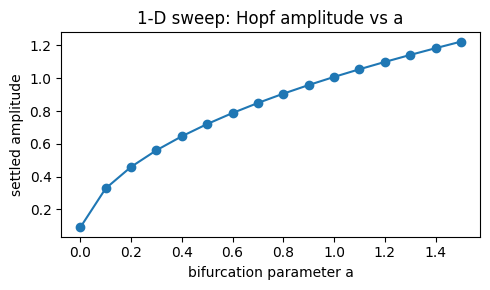

In [3]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.asarray(a_values), np.asarray(amps), 'o-')
ax.set_xlabel('bifurcation parameter a')
ax.set_ylabel('settled amplitude')
ax.set_title('1-D sweep: Hopf amplitude vs a')
fig.tight_layout()
plt.show()

## 2-D sweep → tidy table

For two parameters, build a mesh, flatten it, `vmap` over the flattened pairs,
then reshape the result back to the grid. Here we sweep `a` (bifurcation) against
`w` (intrinsic frequency).

`brainstate.transform.vmap` maps over the leading axis of each argument, so we
pass the two flattened coordinate arrays.


In [4]:
a_grid = jnp.linspace(0.1, 1.5, 6)
w_grid = jnp.linspace(0.1, 0.6, 5)
AA, WW = jnp.meshgrid(a_grid, w_grid, indexing='ij')

def amplitude_aw(a, w):
    node = brainmass.HopfStep(in_size=1, a=a, w=w,
                              init_x=braintools.init.Constant(0.5))
    res = brainmass.Simulator(node, dt=0.1 * u.ms).run(
        150 * u.ms, monitors=['x'], transient=50 * u.ms)
    x = u.get_magnitude(res['x'])[:, 0]
    return jnp.sqrt(jnp.mean(x ** 2)) * jnp.sqrt(2.0)

amp_flat = brainstate.transform.vmap(amplitude_aw)(AA.reshape(-1), WW.reshape(-1))
amp_grid = np.asarray(amp_flat).reshape(AA.shape)
print("grid shape:", amp_grid.shape, "(len(a), len(w))")

grid shape: (6, 5) (len(a), len(w))


Collect the results into a tidy, long-format table. We use a plain dict of
columns (numpy) so there is no hard pandas dependency; convert to a
`pandas.DataFrame` in one line if you have it installed.


In [5]:
table = {
    'a': np.asarray(AA).reshape(-1),
    'w': np.asarray(WW).reshape(-1),
    'amplitude': np.asarray(amp_flat),
}

# Pretty-print the first few rows (pandas optional: pd.DataFrame(table)).
print(f"{'a':>6} {'w':>6} {'amplitude':>10}")
for i in range(8):
    print(f"{table['a'][i]:6.2f} {table['w'][i]:6.2f} {table['amplitude'][i]:10.3f}")
print(f"... ({len(table['a'])} rows total)")

     a      w  amplitude
  0.10   0.10      0.313
  0.10   0.23      0.318
  0.10   0.35      0.325
  0.10   0.48      0.333
  0.10   0.60      0.343
  0.38   0.10      0.609
  0.38   0.23      0.615
  0.38   0.35      0.621
... (30 rows total)


## Heatmap

Visualize the 2-D grid with `brainmass.viz.plot_connectivity` (it draws any
matrix as a labelled heatmap with a colorbar — not just connectomes). The
amplitude depends almost entirely on `a` (the bifurcation parameter), so the
heatmap shows horizontal bands.


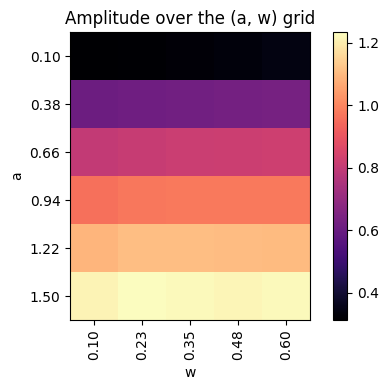

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
brainmass.viz.plot_connectivity(
    amp_grid, ax=ax, cmap='magma',
    labels=None,
)
ax.set_xlabel('w index')
ax.set_ylabel('a index')
ax.set_title('Amplitude over the (a, w) grid')
# annotate the real axis values
ax.set_xticks(range(len(w_grid)))
ax.set_xticklabels([f'{float(w):.2f}' for w in w_grid], rotation=90)
ax.set_yticks(range(len(a_grid)))
ax.set_yticklabels([f'{float(a):.2f}' for a in a_grid])
ax.set_xlabel('w')
ax.set_ylabel('a')
fig.tight_layout()
plt.show()

## Sweeping a network coupling

The same pattern sweeps a *network* parameter. Here we vary the global coupling
strength `k` of a diffusive `Network` and measure the mean functional-connectivity
strength — a standard way to find the coupling regime that best matches data.


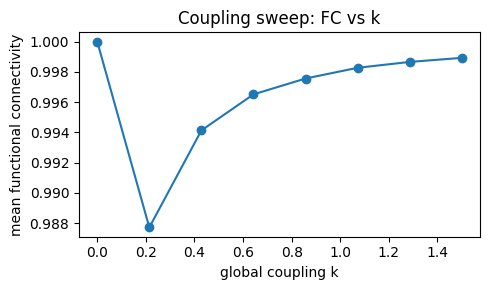

In [7]:
conn = brainmass.datasets.load_dataset('example_connectome')
W, D, N = conn.weights, conn.distances, conn.weights.shape[0]

def mean_fc_for(k):
    node = brainmass.HopfStep(in_size=N, a=0.2, w=0.3,
                              init_x=braintools.init.Constant(0.3))
    net = brainmass.Network(node, conn=W, distance=D, speed=10 * u.mm / u.ms,
                            coupling='diffusive', coupled_var='x', k=k)
    res = brainmass.Simulator(net, dt=0.1 * u.ms).run(
        600 * u.ms, monitors=lambda m: m.node.x.value, transient=100 * u.ms)
    sig = u.get_magnitude(res['output'])
    fc = braintools.metric.functional_connectivity(sig)
    iu = np.triu_indices(N, 1)
    return jnp.mean(fc[iu])

k_values = jnp.linspace(0.0, 1.5, 8)
# A delay-coupled Network reads dt from the global environment at construction,
# so set it once before vmap builds the networks.
brainstate.environ.set(dt=0.1 * u.ms)
mean_fc = brainstate.transform.vmap(mean_fc_for)(k_values)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.asarray(k_values), np.asarray(mean_fc), 'o-')
ax.set_xlabel('global coupling k')
ax.set_ylabel('mean functional connectivity')
ax.set_title('Coupling sweep: FC vs k')
fig.tight_layout()
plt.show()

## Tips

- **Build the model inside the swept function.** `vmap` traces the body once with
  abstract values; constructing the model outside and mutating it does not batch
  correctly.
- **Return a scalar (or fixed-shape) summary.** `vmap` stacks the per-point
  results, so every call must return the same shape.
- **Delay-coupled networks need a global `dt`.** `Network(..., distance=, speed=)`
  sizes its delay buffers from `brainstate.environ.get_dt()` at construction —
  set `dt` once before the sweep (a known ergonomic wrinkle).
- **Fill the device.** A sweep is the natural way to keep a GPU busy; see
  {doc}`/howto/batch_and_accelerate`.

## Next steps

- {doc}`/howto/batch_and_accelerate` — the `vmap` / `jit` mechanics in depth.
- {doc}`/howto/analyze_results` — turn swept trajectories into FC / FCD / spectra.
- {doc}`/tutorials/06_fitting_with_gradients` — let an optimizer *find* the best
  parameters instead of gridding them.
